In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Simulated EdTech Student Data
data = {
    'Student_ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Platform_Logins': [12, 3, 15, 2, 10, 4, 14, 1, 11, 5],
    'Assignments_Completed': [5, 1, 6, 0, 4, 1, 5, 0, 4, 2],
    'Churned': [0, 1, 0, 1, 0, 1, 0, 1, 0, 1] # 0 = Active, 1 = Dropped
}

df = pd.DataFrame(data)
df.head()

,Student_ID,Platform_Logins,Assignments_Completed,Churned
0,1,12,5,0
1,2,3,1,1
2,3,15,6,0
3,4,2,0,1
4,5,10,4,0


In [3]:
X = df[['Platform_Logins', 'Assignments_Completed']]
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Data partitioned for classification training.")

Data partitioned for classification training.


In [4]:
classifier = LogisticRegression()
classifier.fit(X_train, y_train)
print("Logistic Regression model successfully trained.")

Logistic Regression model successfully trained.


In [5]:
predictions = classifier.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("--- Actual vs Predicted Churn ---")
for actual, predicted in zip(y_test, predictions):
    status_actual = "Dropped" if actual == 1 else "Active"
    status_predicted = "Dropped" if predicted == 1 else "Active"
    print(f"Actual: {status_actual} | AI Predicted: {status_predicted}")

Model Accuracy: 100.00%
--- Actual vs Predicted Churn ---
Actual: Active | AI Predicted: Active
Actual: Dropped | AI Predicted: Dropped
Actual: Dropped | AI Predicted: Dropped


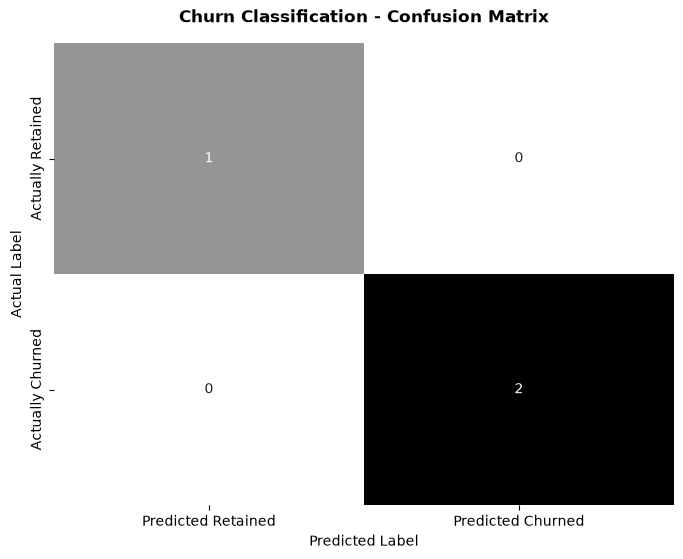

In [6]:
# ==========================================
# DAY 66: CLASSIFICATION METRICS & EVALUATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# ------------------------------------------
# TASK 1: The Confusion Matrix
# ------------------------------------------
# Generate the raw matrix values using YOUR exact variable names
cm = confusion_matrix(y_test, predictions)

# Visualize the matrix with a minimalist aesthetic
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False,
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actually Retained', 'Actually Churned'])
plt.title('Churn Classification - Confusion Matrix', pad=15, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:
# ------------------------------------------
# TASK 2: The Classification Report
# ------------------------------------------
# Print the detailed breakdown of precision, recall, and F1-score
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, predictions, target_names=['Retained (0)', 'Churned (1)']))


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Retained (0)       1.00      1.00      1.00         1
 Churned (1)       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



ROC-AUC Score: 1.0000



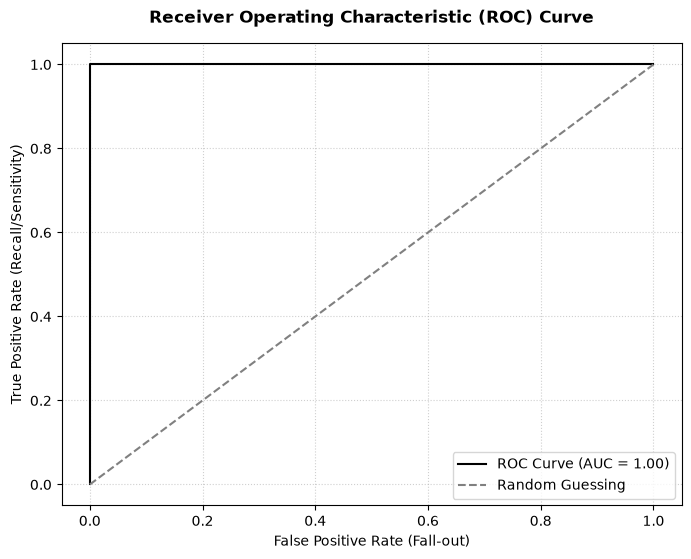

In [8]:
# TASK 3: ROC Curve and AUC Score
# ------------------------------------------
# Extract the probability predictions using your 'classifier' variable
y_prob = classifier.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate (fpr) and True Positive Rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate the AUC (Area Under Curve) score
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}\n")

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='black', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing')

# Formatting the plot
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (Fall-out)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Dataset Successfully Scaled to: 1000 Rows
Class Breakdown:
Churned
0    847
1    153
Name: count, dtype: int64



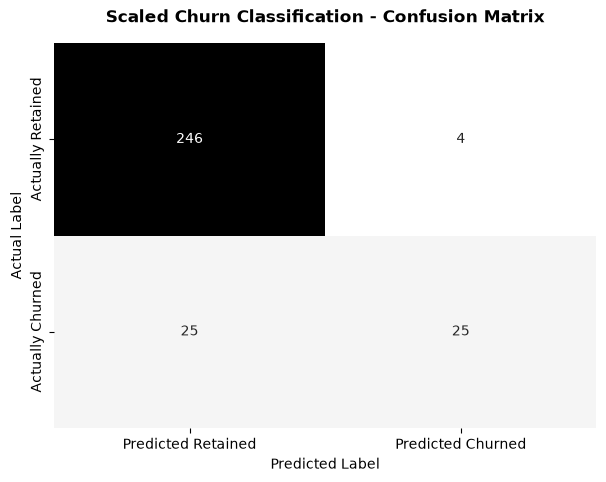


--- SCALED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Retained (0)       0.91      0.98      0.94       250
 Churned (1)       0.86      0.50      0.63        50

    accuracy                           0.90       300
   macro avg       0.88      0.74      0.79       300
weighted avg       0.90      0.90      0.89       300

ROC-AUC Score: 0.9000



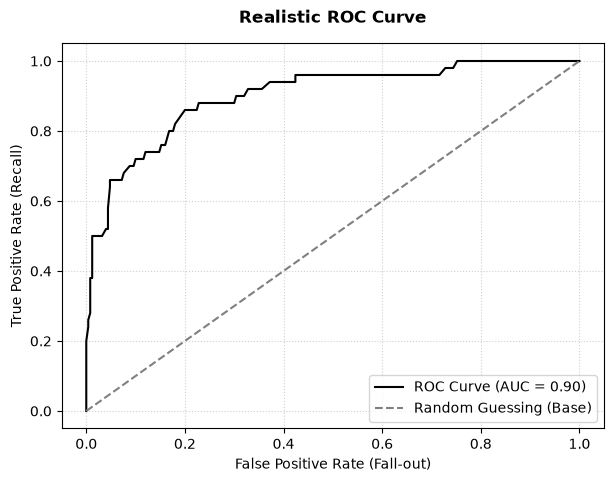

In [9]:
# ==========================================================
# DAY 66: PRODUCTION SCALING & REALISTIC PIPELINE STRESS TEST
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# ----------------------------------------------------------
# 1. SYNTHETIC DATA GENERATION ENGINE (1,000 Users)
# ----------------------------------------------------------
np.random.seed(42)
n_samples = 1000

# Feature A: Platform Logins (Normal distribution around 15 logins)
platform_logins = np.random.normal(loc=15, scale=5, size=n_samples).astype(int)
platform_logins = np.clip(platform_logins, 0, None)  # Enforce non-negative integers

# Feature B: Assignments Completed (Correlated with logins + random noise)
assignments_completed = (platform_logins * 0.6 + np.random.normal(loc=2, scale=3, size=n_samples)).astype(int)
assignments_completed = np.clip(assignments_completed, 0, None)

# Target: Churn Logic (Mathematical probability with injected real-world variance)
# Lower engagement = higher log-odds of churning
log_odds = 3.5 - (0.15 * platform_logins) - (0.4 * assignments_completed)
churn_probability = 1 / (1 + np.exp(-log_odds))
churned_labels = np.random.binomial(1, churn_probability)

# Assemble the new data framework
df_scaled = pd.DataFrame({
    'Platform_Logins': platform_logins,
    'Assignments_Completed': assignments_completed,
    'Churned': churned_labels
})

# ----------------------------------------------------------
# 2. THE TECHNICAL DATA PIPELINE
# ----------------------------------------------------------
X = df_scaled[['Platform_Logins', 'Assignments_Completed']]
y = df_scaled['Churned']

# Execute a clean 70/30 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the classifier using your exact variable architecture
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Generate predictions and probability arrays
predictions = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:, 1]

# ----------------------------------------------------------
# 3. METRIC PIPELINE OUTPUTS
# ----------------------------------------------------------
print(f"Dataset Successfully Scaled to: {df_scaled.shape[0]} Rows")
print(f"Class Breakdown:\n{df_scaled['Churned'].value_counts()}\n")

# A. Visualizing the Real-World Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False,
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actually Retained', 'Actually Churned'])
plt.title('Scaled Churn Classification - Confusion Matrix', pad=15, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# B. Generating the Real-World Classification Report
print("\n--- SCALED CLASSIFICATION REPORT ---")
print(classification_report(y_test, predictions, target_names=['Retained (0)', 'Churned (1)']))

# C. Plotting the Realistic ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}\n")

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='black', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (Base)')
plt.title('Realistic ROC Curve', fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (Fall-out)')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

--- EVALUATING CUSTOM THRESHOLD: 0.3 ---


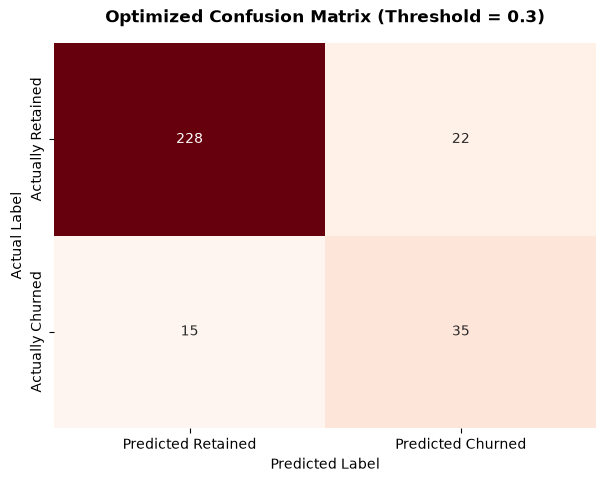


--- ADJUSTED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Retained (0)       0.94      0.91      0.92       250
 Churned (1)       0.61      0.70      0.65        50

    accuracy                           0.88       300
   macro avg       0.78      0.81      0.79       300
weighted avg       0.88      0.88      0.88       300



In [10]:
# ==========================================================
# DAY 66: THRESHOLD OPTIMIZATION (MAXIMIZING RECALL)
# ==========================================================

# 1. Manually Override the Default 0.50 Threshold
custom_threshold = 0.30

# Apply the new logic: If probability >= 30%, predict Churn (1). Else, predict Retained (0).
adjusted_predictions = (y_prob >= custom_threshold).astype(int)

# 2. Evaluate the Business Impact
print(f"--- EVALUATING CUSTOM THRESHOLD: {custom_threshold} ---")

# Generate the adjusted confusion matrix
cm_adjusted = confusion_matrix(y_test, adjusted_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actually Retained', 'Actually Churned'])
plt.title(f'Optimized Confusion Matrix (Threshold = {custom_threshold})', pad=15, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Generate the adjusted classification report
print("\n--- ADJUSTED CLASSIFICATION REPORT ---")
print(classification_report(y_test, adjusted_predictions, target_names=['Retained (0)', 'Churned (1)']))

--- RANDOM FOREST CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Retained (0)       0.91      0.93      0.92       250
 Churned (1)       0.60      0.52      0.56        50

    accuracy                           0.86       300
   macro avg       0.76      0.73      0.74       300
weighted avg       0.86      0.86      0.86       300



C:\Users\mayan\AppData\Local\Temp\ipykernel_13920\2912593969.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Score', y='Feature', data=feature_df, palette='dark:black')


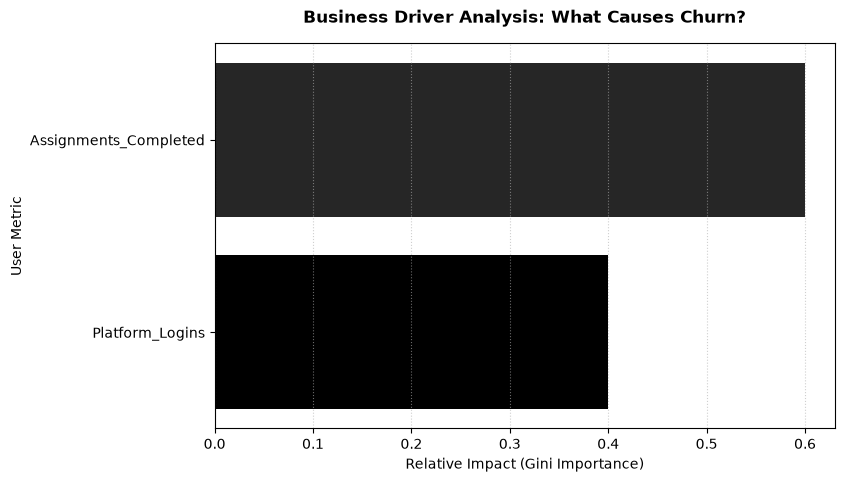

In [11]:
# ==========================================================
# DAY 67: RANDOM FOREST & FEATURE IMPORTANCE
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Train the Random Forest Model
# n_estimators=100 means we are building a forest of 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Generate Predictions
rf_predictions = rf_model.predict(X_test)

# 3. Evaluate the Ensemble Performance
print("--- RANDOM FOREST CLASSIFICATION REPORT ---")
print(classification_report(y_test, rf_predictions, target_names=['Retained (0)', 'Churned (1)']))

# 4. Extract and Visualize Feature Importance
# Extract the mathematical importance of each column
importances = rf_model.feature_importances_
feature_names = X.columns

# Bind them into a clean DataFrame for visualization
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

# Plot the Business Insight
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance_Score', y='Feature', data=feature_df, palette='dark:black')
plt.title('Business Driver Analysis: What Causes Churn?', fontweight='bold', pad=15)
plt.xlabel('Relative Impact (Gini Importance)')
plt.ylabel('User Metric')
plt.grid(True, axis='x', linestyle=':', alpha=0.6)
plt.show()